In [1]:
print("Hello Nassau Project")

Hello Nassau Project


In [2]:
import pandas as pd

df = pd.read_csv('data/Nassau Candy Distributor.csv')

df.head()

EmptyDataError: No columns to parse from file

In [3]:
import pandas as pd

df = pd.read_csv('data/Nassau Candy Distributor.csv')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [4]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Country/Region', 'City', 'State/Province',
       'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name',
       'Sales', 'Units', 'Gross Profit', 'Cost'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

In [6]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

In [7]:
df = df.drop_duplicates()

print("Duplicates Removed")

Duplicates Removed


In [10]:
df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    dayfirst=True
)

df['Ship Date'] = pd.to_datetime(
    df['Ship Date'],
    dayfirst=True
)

In [11]:
df['Lead_Time'] = (
    df['Ship Date'] - df['Order Date']
).dt.days

In [12]:
df[['Order Date', 'Ship Date', 'Lead_Time']].head()

,Order Date,Ship Date,Lead_Time
0,2024-01-03,2026-06-30,909
1,2024-01-04,2026-07-01,909
2,2024-01-04,2026-07-01,909
3,2024-01-04,2026-07-01,909
4,2024-01-05,2026-07-05,912


In [13]:
factory_map = {
    "Wonka Bar - Nutty Crunch Surprise": "Lot's O' Nuts",
    "Wonka Bar - Fudge Mallows": "Lot's O' Nuts",
    "Wonka Bar -Scrumdiddlyumptious": "Lot's O' Nuts",
    "Wonka Bar - Milk Chocolate": "Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel": "Wicked Choccy's",
    "Laffy Taffy": "Sugar Shack",
    "SweeTARTS": "Sugar Shack",
    "Nerds": "Sugar Shack",
    "Fun Dip": "Sugar Shack",
    "Fizzy Lifting Drinks": "Sugar Shack",
    "Everlasting Gobstopper": "Secret Factory",
    "Hair Toffee": "The Other Factory",
    "Lickable Wallpaper": "Secret Factory",
    "Wonka Gum": "Secret Factory",
    "Kazookles": "The Other Factory"
}

In [14]:
df['Factory'] = df['Product Name'].map(factory_map)

In [15]:
df[['Product Name', 'Factory']].head(10)

,Product Name,Factory
0,Wonka Bar - Milk Chocolate,Wicked Choccy's
1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's
5,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts
6,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's
7,Wonka Bar - Milk Chocolate,Wicked Choccy's
8,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts
9,Wonka Bar - Milk Chocolate,Wicked Choccy's


In [16]:
df['Factory'].value_counts()

Factory
Lot's O' Nuts        5692
Wicked Choccy's      4152
Secret Factory        217
The Other Factory     100
Sugar Shack            33
Name: count, dtype: int64

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

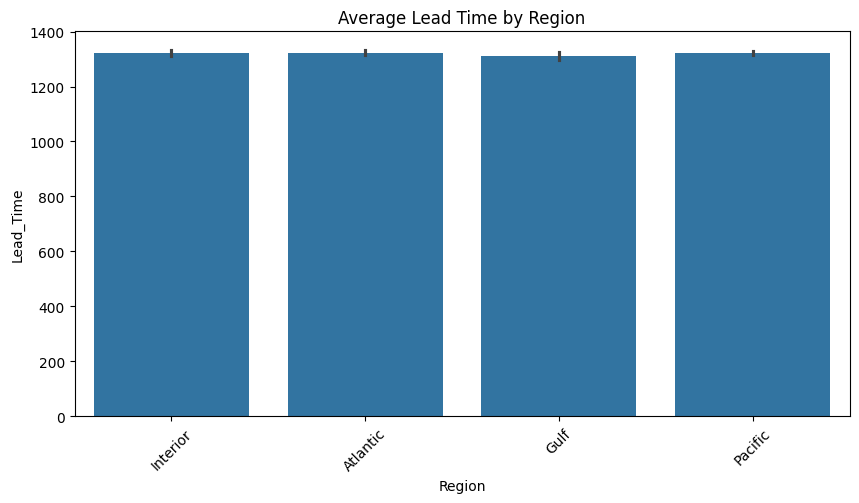

In [18]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Region',
    y='Lead_Time',
    data=df
)

plt.title("Average Lead Time by Region")

plt.xticks(rotation=45)

plt.show()

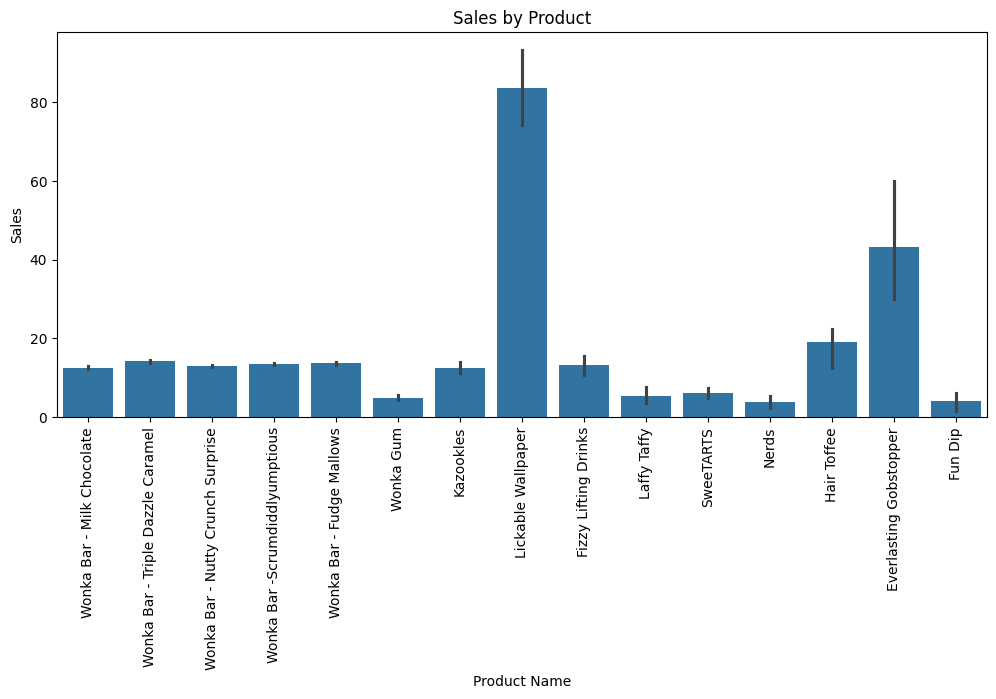

In [19]:
plt.figure(figsize=(12,5))

sns.barplot(
    x='Product Name',
    y='Sales',
    data=df
)

plt.xticks(rotation=90)

plt.title("Sales by Product")

plt.show()

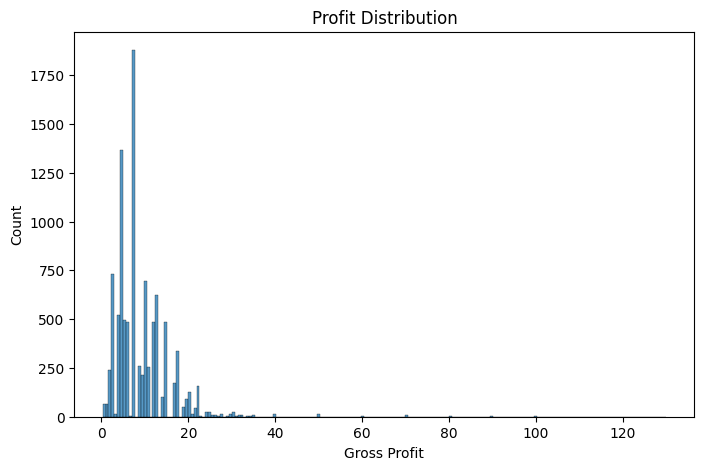

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(df['Gross Profit'])

plt.title("Profit Distribution")

plt.show()

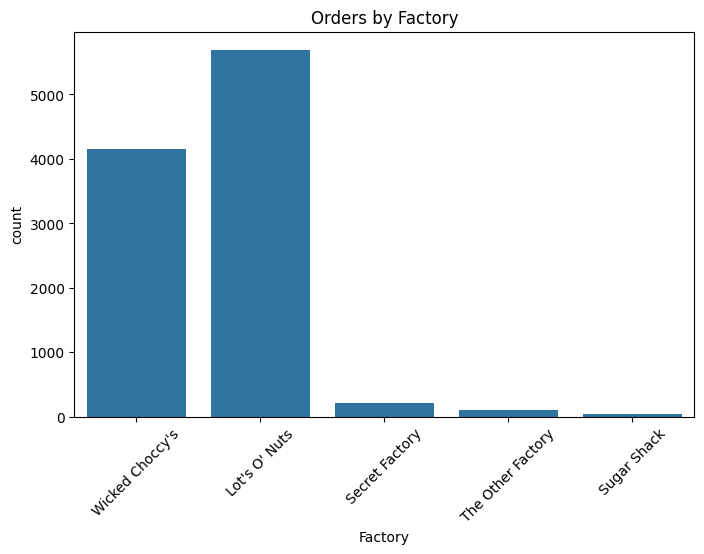

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Factory',
    data=df
)

plt.xticks(rotation=45)

plt.title("Orders by Factory")

plt.show()

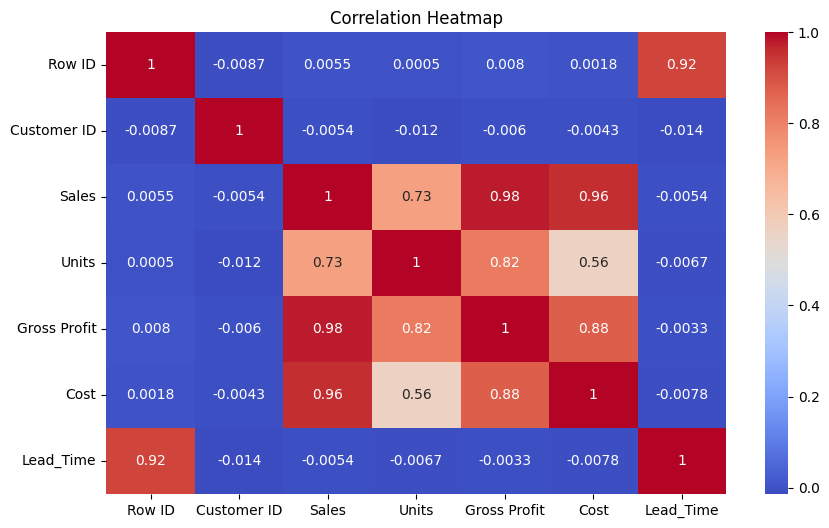

In [22]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [23]:
from sklearn.preprocessing import LabelEncoder

In [24]:
le = LabelEncoder()

In [25]:
df['Region'] = le.fit_transform(df['Region'])

df['Ship Mode'] = le.fit_transform(df['Ship Mode'])

df['Factory'] = le.fit_transform(df['Factory'])

df['Product Name'] = le.fit_transform(df['Product Name'])

In [26]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Lead_Time,Factory
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,3,103800,United States,Houston,Texas,77095,Chocolate,2,CHO-MIL-31000,10,6.50,2,4.22,2.28,909,4
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,3,112326,United States,Naperville,Illinois,60540,Chocolate,2,CHO-TRI-54000,12,7.50,2,4.90,2.60,909,4
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,3,112326,United States,Naperville,Illinois,60540,Chocolate,2,CHO-NUT-13000,11,10.47,3,7.47,3.00,909,0
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,3,112326,United States,Naperville,Illinois,60540,Chocolate,2,CHO-SCR-58000,13,10.80,3,7.50,3.30,909,0
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,3,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,0,CHO-TRI-54000,12,11.25,3,7.35,3.90,912,4


In [27]:
X = df[['Region', 'Ship Mode', 'Factory', 'Sales', 'Units']]

In [28]:
y = df['Lead_Time']

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [30]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()

In [31]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [32]:
predictions = model.predict(X_test)

In [33]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    y_test,
    predictions
)

print("MAE:", mae)

MAE: 224.1003956528121


In [34]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, predictions)

print("R2 Score:", r2)

R2 Score: -0.07980690187594908


In [35]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance

,Feature,Importance
0,Region,0.250318
1,Ship Mode,0.165952
2,Factory,0.097066
3,Sales,0.352358
4,Units,0.134307


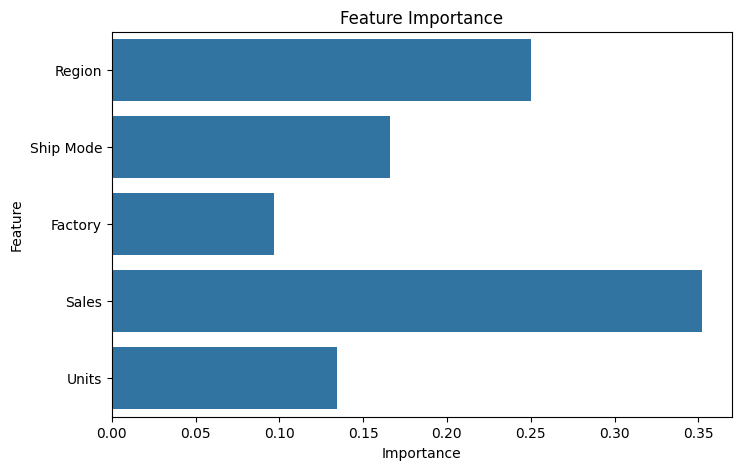

In [36]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")

plt.show()

In [37]:
df[['Product Name', 'Factory']].head(10)

,Product Name,Factory
0,10,4
1,12,4
2,11,0
3,13,0
4,12,4
5,13,0
6,12,4
7,10,4
8,11,0
9,10,4


In [38]:
factories = df['Factory'].unique()

print(factories)

[4 0 1 3 2]


In [39]:
sample = X.iloc[0].copy()

sample

Region       2.0
Ship Mode    3.0
Factory      4.0
Sales        6.5
Units        2.0
Name: 0, dtype: float64

In [41]:
results = []

for factory in factories:
    
    temp = sample.copy()
    
    temp['Factory'] = factory
    
    temp_df = pd.DataFrame([temp])
    
    prediction = model.predict(temp_df)[0]
    
    results.append({
        'Factory': factory,
        'Predicted_Lead_Time': prediction
    })

In [42]:
results_df = pd.DataFrame(results)

results_df

,Factory,Predicted_Lead_Time
0,4,1321.845917
1,0,1270.163836
2,1,1271.720522
3,3,1180.771701
4,2,1256.834723


In [43]:
best_factory = results_df.loc[
    results_df['Predicted_Lead_Time'].idxmin()
]

best_factory

Factory                   3.000000
Predicted_Lead_Time    1180.771701
Name: 3, dtype: float64